# Latihan QUIZ CV

Fadhlan Nur Rachman - 2802491690

Pipeline:
- Import Library
- Dataset Load & Description
- Image Preprocessing
- Feature Detection
- Feature Matching
- Result

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img = cv2.imread('images/target/hina.png')
print(img.shape)

(172, 194, 3)


# Dataset Load and Description

In [20]:
DATA_PATH = 'images/source/'
data = []

for img_path in os.listdir(DATA_PATH):
    img_path = DATA_PATH + img_path
    img_path = cv2.imread(img_path)
    data.append(img_path)


# Image Preprocessing

In [21]:

target_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# jadi grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# filtering blur
gray_img = cv2.GaussianBlur(gray_img, (3, 3), 0) # Gaussian Blur kernel size 3x3
# gray_img = cv2.medianBlur(gray_img, 3) # Median Blur kernel size 3
# gray_img = cv2.bilateralFilter(gray_img, 0, 75, 75) # Bilateral Filter kernel size 75

# histogram equalization biar smooth warnanya
gray_img = cv2.equalizeHist(gray_img)

# Initialize Feature Detection Algorithm

In [22]:
sift = cv2.SIFT_create()
akaze = cv2.AKAZE_create()
orb = cv2.ORB_create()

# Detect Keypoints and Descriptors
target_kp, target_des = sift.detectAndCompute(gray_img, None) # SIFT
# target_kp, target_des = akaze.detectAndCompute(gray_img, None) # AKAZE
# target_kp, target_des = orb.detectAndCompute(gray_img, None) # ORB

# convert ke float32 supaya bisa diproses oleh algoritma selanjutnya
target_des = np.float32(target_des)

# Initialize Bast Matches
best_matches = 0
best_matches_data = None
best_ratio = None
ratio_values = [0.5]

# Loop Data Image & Feature Matching with Flann

In [23]:
for idx, img in enumerate(data):

    # Preprocessing
    img_view = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray_data = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_img = cv2.GaussianBlur(gray_data, (3, 3), 0) # Gaussian Blur kernel size 3x3
    gray_data = cv2.equalizeHist(gray_data)

    # keypoint and descriptor
    img_kp, img_des = sift.detectAndCompute(gray_data, None) # SIFT
    # img_kp, img_des = akaze.detectAndCompute(gray_data, None) # AKAZE
    # img_kp, img_des = orb.detectAndCompute(gray_data, None) # ORB
    
    img_des = np.float32(img_des)

    # FLANN Matcher
    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50)) # SIFT & AKAZE
    # flann = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False) # ORB
    matches = flann.knnMatch(target_des, img_des, k=2)

    for ratio in ratio_values:
        matches_mask = [[0, 0] for _ in range(0, len(matches))]
        current_matches = 0

        for i, (fm, fn) in enumerate(matches):
            if fm.distance < ratio * fn.distance:
                matches_mask[i] = [1, 0]
                current_matches += 1
        
    if current_matches > best_matches:
        best_matches = current_matches
        best_ratio = ratio
        best_matches_data = {
            'image_data': img_view,
            'keypoints': img_kp,
            'descriptors': img_des,
            'matches': matches,
            'matches_mask': matches_mask
        }

# Result

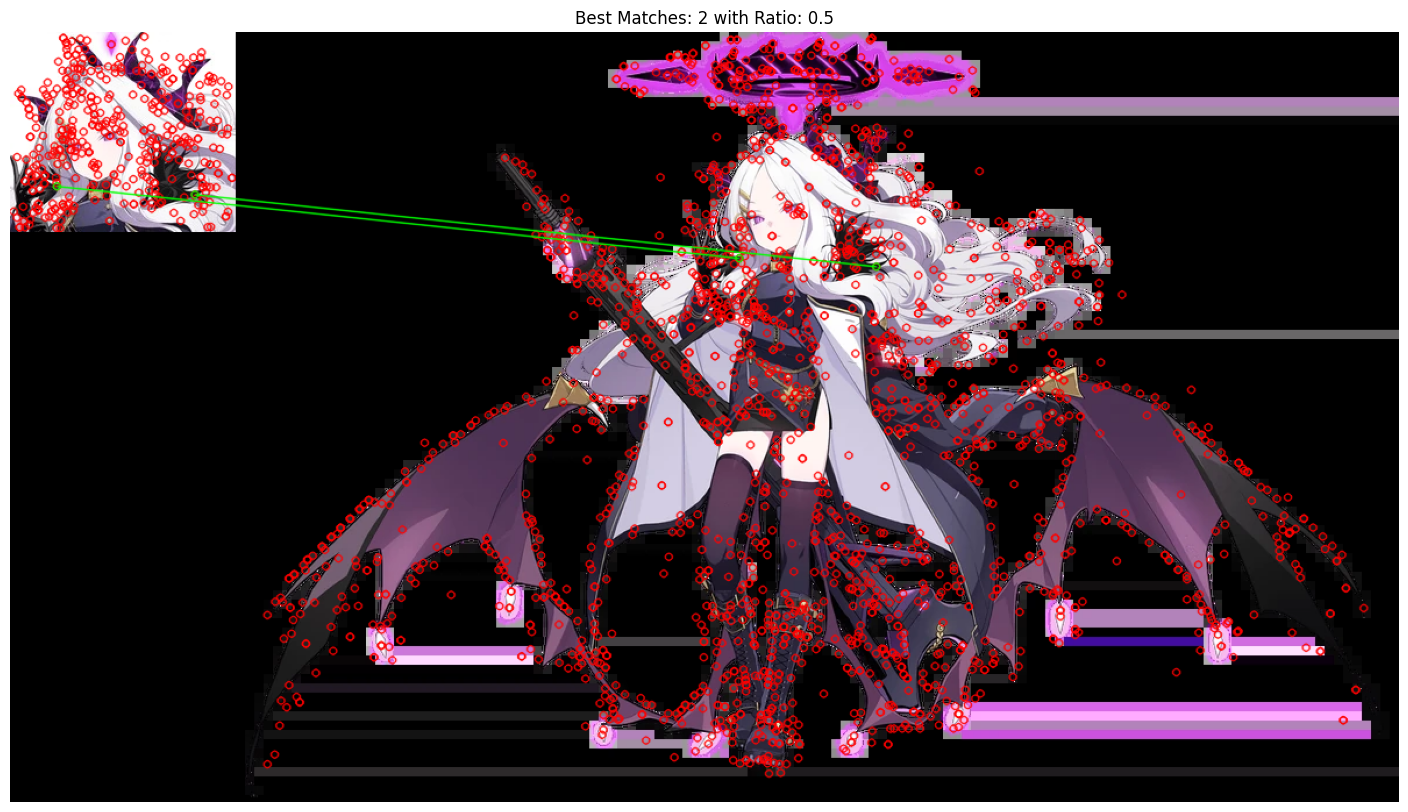

In [24]:
result = cv2.drawMatchesKnn(
    target_img,
    target_kp,
    best_matches_data['image_data'],
    best_matches_data['keypoints'],
    best_matches_data['matches'],
    None,
    matchesMask=best_matches_data['matches_mask'],
    matchColor=(0, 255, 0),
    singlePointColor=(255, 0, 0),
)

plt.figure(figsize=(20,10))
plt.imshow(result)
plt.title(f'Best Matches: {best_matches} with Ratio: {best_ratio}')
plt.axis('off')
plt.show()